## 1. Chargement du dataset


In [12]:
import pandas as pd

df = pd.read_csv("Insuffisance Rénale L3.csv", index_col=0)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1.0,1.0,1.0,1.0,121.0,...,44.0,7800.0,5.2,0.0,0.0,1.0,1.0,1.0,1.0,ckd
1,7.0,50.0,1.020,4.0,0.0,1.0,1.0,1.0,1.0,121.0,...,38.0,6000.0,4.8,1.0,1.0,1.0,1.0,1.0,1.0,ckd
2,62.0,80.0,1.010,2.0,3.0,1.0,1.0,1.0,1.0,423.0,...,31.0,7500.0,4.8,1.0,0.0,1.0,0.0,1.0,0.0,ckd
3,48.0,70.0,1.005,4.0,0.0,1.0,0.0,0.0,1.0,117.0,...,32.0,6700.0,3.9,0.0,1.0,1.0,0.0,0.0,0.0,ckd
4,51.0,80.0,1.010,2.0,0.0,1.0,1.0,1.0,1.0,106.0,...,35.0,7300.0,4.6,1.0,1.0,1.0,1.0,1.0,1.0,ckd


## 2. Taille et valeurs manquantes

In [30]:
print("Taille du dataset :", df.shape)

print("\nValeurs manquantes :")
print(df.isna().sum())

Taille du dataset : (400, 27)

Valeurs manquantes :
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wbcc              0
rbcc              0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
class             0
cluster           0
cluster_scaled    0
dtype: int64


## 3. Statistiques descriptives des variables

In [14]:
df.describe()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
count,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.00000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000
mean,51.562500,76.575000,1.017712,0.90000,0.395000,0.882500,0.810000,0.895000,0.945000,145.062500,...,12.54250,39.082500,8298.500000,4.737750,0.632500,0.65750,0.915000,0.795000,0.810000,0.850000
std,16.982996,13.489785,0.005434,1.31313,1.040038,0.322418,0.392792,0.306937,0.228266,75.260774,...,2.71649,8.162245,2529.593814,0.841439,0.482728,0.47514,0.279231,0.404207,0.392792,0.357519
min,2.000000,50.000000,1.005000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,...,3.10000,9.000000,2200.000000,2.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,70.000000,1.015000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,101.000000,...,10.87500,34.000000,6975.000000,4.500000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000
50%,55.000000,80.000000,1.020000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,121.000000,...,12.65000,40.000000,8000.000000,4.800000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
75%,64.000000,80.000000,1.020000,2.00000,0.000000,1.000000,1.000000,1.000000,1.000000,150.000000,...,14.62500,44.000000,9400.000000,5.100000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
max,90.000000,180.000000,1.025000,5.00000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,...,17.80000,54.000000,26400.000000,8.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


## 4. Données sans la feature cible

In [15]:
X = df.drop(columns=["class"])

## 5. Dendrogramme (CAH)

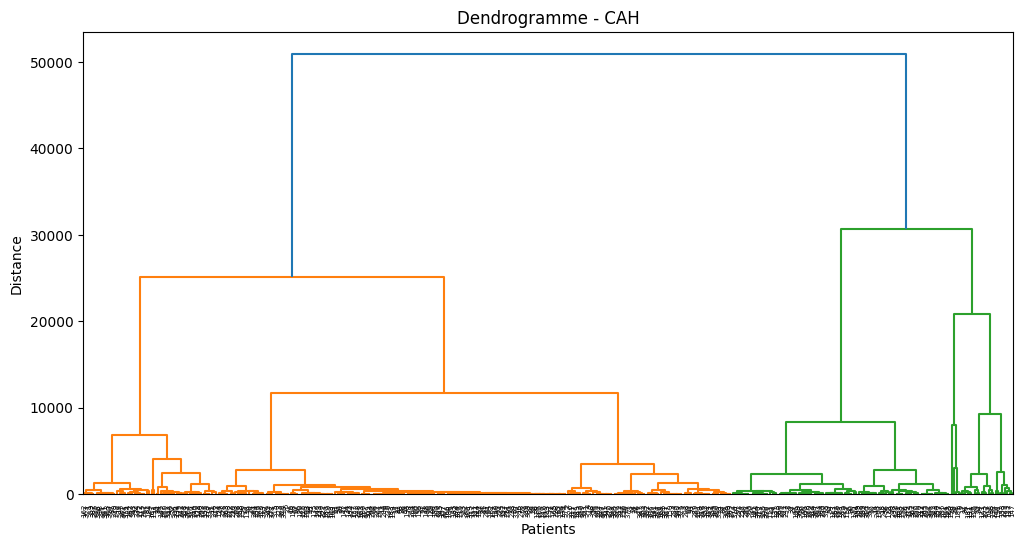

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X, method='ward')

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Dendrogramme - CAH")
plt.xlabel("Patients")
plt.ylabel("Distance")
plt.show()

## 5. Dendrogramme tronqué (visualisation)

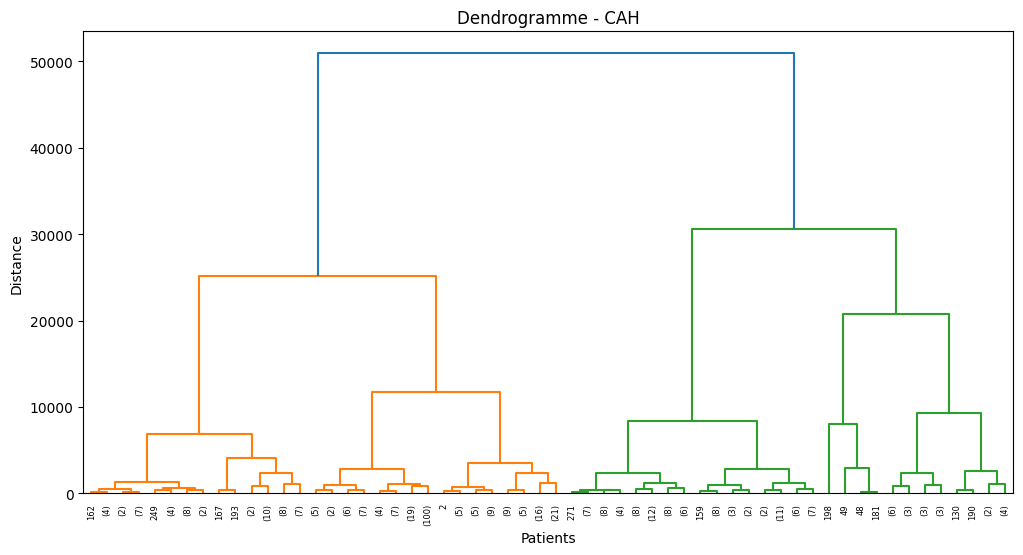

In [17]:
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrogramme - CAH")
plt.xlabel("Patients")
plt.ylabel("Distance")
plt.show()


## 6. AgglomerativeClustering – 3 clusters

In [21]:

X = df.drop(columns=["class"])

from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3)
clusters = model.fit_predict(X)


df["cluster"] = clusters

## 7. Insuffisance rénale par cluster

In [22]:
pd.crosstab(df["cluster"], df["class"])

class,ckd,notckd
cluster,,
0,175,104
1,27,0
2,48,46


EXERCICE 2
1. Normalisation

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Comment se répartissent les données

In [24]:
X_scaled[:5]

array([[-0.21003135,  0.25421378,  0.4214856 ,  0.07624929, -0.38026942,
         0.36488968,  0.4843221 ,  0.34251779,  0.24124895, -0.32012207,
        -0.41945149, -0.31966815,  0.04010412, -0.06290305,  1.05322632,
         0.60322353, -0.19731401,  0.55004435, -1.3119026 , -1.38553529,
         0.30478874,  0.50780078,  0.4843221 ,  0.42008403],
       [-2.62723421, -1.97247624,  0.4214856 ,  2.36372784, -0.38026942,
         0.36488968,  0.4843221 ,  0.34251779,  0.24124895, -0.32012207,
        -0.78431531, -0.39081916,  0.04010412, -0.06290305, -0.45796455,
        -0.13278891, -0.90978184,  0.07407304,  0.76225171,  0.72174272,
         0.30478874,  0.50780078,  0.4843221 ,  0.42008403],
       [ 0.615355  ,  0.25421378, -1.4210744 ,  0.83874214,  2.50785277,
         0.36488968,  0.4843221 ,  0.34251779,  0.24124895,  3.69761778,
        -0.07485789, -0.21294164,  0.04010412, -0.06290305, -1.08455588,
        -0.99147009, -0.31605865,  0.07407304,  0.76225171, -1.38553529,
  

Nouveau dendrogramme

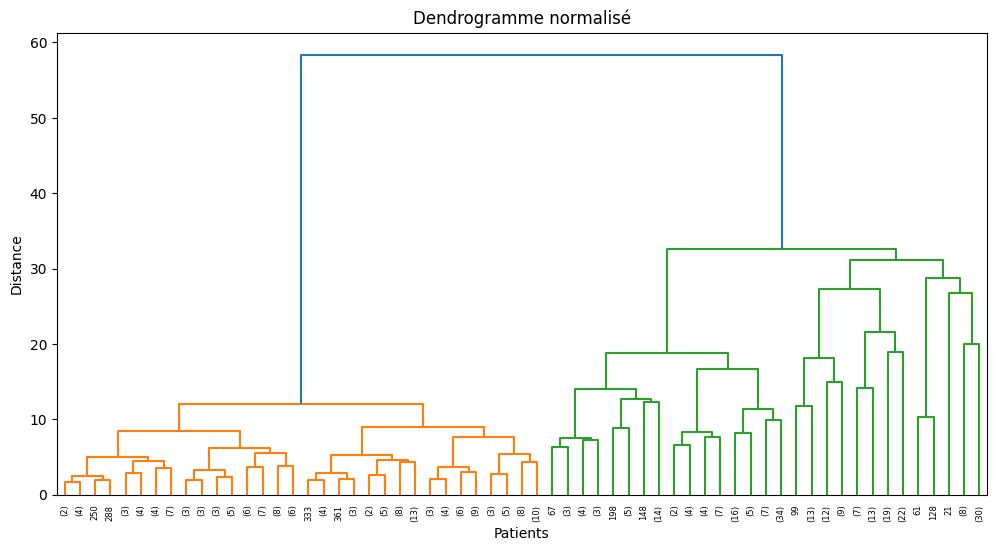

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z_scaled = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(Z_scaled, truncate_mode="level", p=5)
plt.title("Dendrogramme normalisé")
plt.xlabel("Patients")
plt.ylabel("Distance")
plt.show()

Interprétation dendrogramme

👉 Dans responses.md

Clustering (3 clusters)

In [26]:
from sklearn.cluster import AgglomerativeClustering

model_scaled = AgglomerativeClustering(n_clusters=3)
clusters_scaled = model_scaled.fit_predict(X_scaled)

df["cluster_scaled"] = clusters_scaled

Répartition classes vs clusters

In [27]:
pd.crosstab(df["cluster_scaled"], df["class"])

class,ckd,notckd
cluster_scaled,,
0,137,0
1,2,150
2,111,0


Interprétation

👉 Dans responses.md 